# Assignment 1
# Andrew Silveira
# 5077086

## Problem 1: Pick-and-Place Robot

State Space (S)

•	Joint angles: θ₁, θ₂, …, θₙ

•	Joint angular velocities: θ̇₁, θ̇₂, …, θ̇ₙ

•	Gripper status: open or closed

•	Object status: grasped or not grasped

A state can be written as:
s = [θ₁ … θₙ, θ̇₁ … θ̇ₙ, gripper status, object status]

Reasoning:
To learn smooth, fast trajectories, the agent must know both positions and velocities. Gripper and object status are essential for determining whether the robot is carrying the object.


Action Space (A)
Actions correspond to direct motor commands, such as:

•	Joint torque commands: [τ₁, τ₂, …, τₙ]

•	Discretized velocity adjustments per joint

•	Gripper open/close

Reasoning:
Direct motor control is required to learn smooth, continuous movements.


Transition Function (P(s′|s,a))
Robot motion follows deterministic physics:
s′ = f(s, a)
where f is the robot’s dynamics model.

Reasoning: Robot arms have predictable, low noise dynamics.


Reward Function (R)

A reward design that encourages fast, smooth, successful pick and place behavior:

•	+100 for successfully placing the object at the target

•	+10 for successfully grasping the object

•	−1 per time step (encourages speed)

•	−α‖θ̇‖ to encourage smooth motion

•	−50 for dropping the object or collisions

Reasoning: Rewards encode task success, efficiency, smoothness, and safety.


## Problem 2: 2×2 Gridworld: Value Iteration

Grid layout:
	
	
Actions: up, down, left, right
Invalid actions → remain in same state
Discount factor: γ = 1

Iteration 0 – Initial Values

V₀(s) = 0 for all states

Iteration 1 – Value Updates

Value iteration update rule:
Vₖ₊₁(s) = R(s) + γ maxₐ Vₖ(s′)

Since all V₀ = 0:

State s1
Next states: s1, s1, s2, s3
V₁(s1) = 5 + max(0, 0, 0, 0) = 5

State s2
Next states: s2, s2, s1, s4
V₁(s2) = 10 + max(0, 0, 0, 0) = 10

State s3
Next states: s3, s3, s4, s1
V₁(s3) = 1 + max(0, 0, 0, 0) = 1

State s4
Next states: s4, s4, s3, s2
V₁(s4) = 2 + max(0, 0, 0, 0) = 2

Iteration 1 Result
V₁ = {s1: 5, s2: 10, s3: 1, s4: 2}

Iteration 2 – Value Updates

State s1
V₂(s1) = 5 + max(5, 5, 10, 1) = 15

State s2
V₂(s2) = 10 + max(10, 10, 5, 2) = 20

State s3
V₂(s3) = 1 + max(1, 1, 2, 5) = 6

State s4
V₂(s4) = 2 + max(2, 2, 1, 10) = 12

Iteration 2 Result
V₂ = {s1: 15, s2: 20, s3: 6, s4: 12}


## Problem 3: 5x5 Gridworld

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from gridworld import GridWorld

ENV_SIZE = 5

class ValueIteration:
    def __init__(self, env, theta=0.001):
        self.env = env
        self.env_size = env.get_size()
        self.V = np.zeros((self.env_size, self.env_size))
        self.gamma = 0.9
        self.theta = theta
        self.policy = np.zeros((self.env_size, self.env_size), dtype=int)

    def run(self):
        while True:
            delta = 0
            new_V = np.copy(self.V)

            for i in range(self.env_size):
                for j in range(self.env_size):
                    state = (i,j)
                    if self.env.is_terminal_state(i,j) or state in self.env.grey_states:
                        continue
                    
                    max_value = -float("inf")

                    for a in range(len(self.env.actions)):
                        next_i, next_j, reward, _ = self.env.step(a, i, j)
                        value = reward + self.gamma * self.V[next_i, next_j]

                        if value > max_value:
                            max_value = value

                    new_V[i,j] = max_value
                    delta = max(delta, abs(self.V[i,j] - new_V[i,j]))

            self.V = new_V

            if delta < self.theta:
                break

        self.extract_policy()
        
    def run_in_place(self):
        while True:
            delta = 0

            for i in range(self.env_size):
                for j in range(self.env_size):

                    if self.env.is_terminal_state(i, j):
                        continue

                    max_value = -float("inf")
                    best_action = 0

                    for a in range(len(self.env.actions)):
                        next_i, next_j, reward, _ = self.env.step(a, i, j)
                        value = reward + self.gamma * self.V[next_i, next_j]

                        if value > max_value:
                            max_value = value
                            best_action = a

                    # In‑place update
                    old_value = self.V[i, j]
                    self.V[i, j] = max_value

                    delta = max(delta, abs(old_value - max_value))

            if delta < self.theta:
                break

        self.extract_policy()

    def extract_policy(self):
        for i in range(self.env_size):
            for j in range(self.env_size):
                state = (i,j)
                if self.env.is_terminal_state(i,j) or state in self.env.grey_states:
                    self.policy[i,j] = -1 if self.env.is_terminal_state(i,j) else -5
                    continue
                
                max_value = -float("inf")
                best_action = 0

                for a in range(len(self.env.actions)):
                    next_i, next_j, reward, _ = self.env.step(a, i, j)
                    value = reward + self.gamma * self.V[next_i, next_j]

                    if value > max_value:
                        max_value = value
                        best_action = a

                self.policy[i,j] = best_action
                
def visualize(V, P):
    # -----------------------------
    # 1. Heatmap of V*
    # -----------------------------
    plt.figure(figsize=(6, 5))
    plt.imshow(V, cmap='viridis', origin='upper')
    plt.colorbar(label='Value')
    plt.title("Optimal Value Function V*")
    plt.xlabel("Column")
    plt.ylabel("Row")

    # Add value labels
    for i in range(V.shape[0]):
        for j in range(V.shape[1]):
            plt.text(j, i, f"{V[i,j]:.1f}", ha='center', va='center', color='white')

    plt.show()

    # -----------------------------
    # 2. Quiver plot of π*
    # -----------------------------
    action_to_vector = {
        0: (1, 0),    # Right
        1: (-1, 0),   # Left
        2: (0, 1),    # Down
        3: (0, -1),   # Up
        -1: (0, 0),   # Terminal
        -5: (0, 0),   # Grey state
    }

    rows, cols = P.shape
    X, Y = np.meshgrid(np.arange(cols), np.arange(rows))

    U = np.zeros_like(P, dtype=float)
    Vv = np.zeros_like(P, dtype=float)

    for i in range(rows):
        for j in range(cols):
            if P[i, j] == -5:
                continue
            
            dx, dy = action_to_vector[P[i, j]]
            U[i, j] = dx
            Vv[i, j] = dy  # invert y-axis for plotting

    plt.figure(figsize=(6, 5))
    plt.quiver(X, Y, U, Vv, angles='xy', scale_units='xy', scale=1)
    
    # Put row 0 at the top
    plt.gca().invert_yaxis()
    
    plt.title("Optimal Policy π*")
    plt.xlabel("Column")
    plt.ylabel("Row")

    # Mark terminal state
    for i in range(rows):
        for j in range(cols):
            if P[i, j] == -1:
                plt.text(j, i, "T", ha='center', va='center', fontsize=14, color='red')

    plt.show()                

# Run value iteration
env = GridWorld(ENV_SIZE)
agent = ValueIteration(env)
agent.run()

print("Optimal Value Function:")
print(agent.V)

print("\nOptimal Policy (0=Right,1=Left,2=Down,3=Up,-1=Terminal):")
print(agent.policy)


Optimal Value Function:
[[-0.434062  0.62882   1.8098    3.122     0.      ]
 [ 0.62882   1.8098    0.        4.58      6.2     ]
 [ 1.8098    3.122     4.58      6.2       8.      ]
 [ 0.        4.58      6.2       8.       10.      ]
 [ 4.58      6.2       8.       10.        0.      ]]

Optimal Policy (0=Right,1=Left,2=Down,3=Up,-1=Terminal):
[[ 0  0  0  2 -5]
 [ 0  2 -5  0  2]
 [ 0  0  0  0  2]
 [-5  0  0  0  2]
 [ 0  0  0  0 -1]]


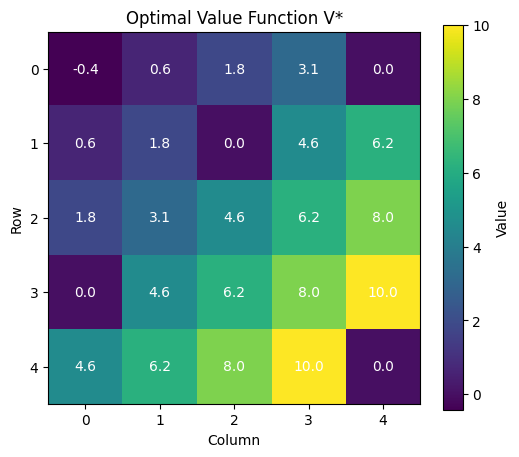

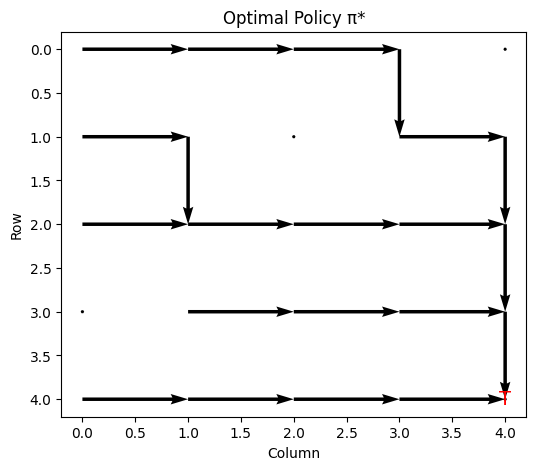

In [27]:
visualize(agent.V, agent.policy)

In [28]:
print("\nNow running In-place Value Iteration:")
agent.run_in_place()

print("\nIn-place Optimal Value Function:")
print(agent.V)

print("\nIn-place Optimal Policy (0=Right,1=Left,2=Down,3=Up,-1=Terminal):")
print(agent.policy)


Now running In-place Value Iteration:

In-place Optimal Value Function:
[[-0.434062  0.62882   1.8098    3.122     4.58    ]
 [ 0.62882   1.8098    3.122     4.58      6.2     ]
 [ 1.8098    3.122     4.58      6.2       8.      ]
 [ 3.122     4.58      6.2       8.       10.      ]
 [ 4.58      6.2       8.       10.        0.      ]]

In-place Optimal Policy (0=Right,1=Left,2=Down,3=Up,-1=Terminal):
[[ 0  0  0  2 -5]
 [ 0  2 -5  0  2]
 [ 0  0  0  0  2]
 [-5  0  0  0  2]
 [ 0  0  0  0 -1]]


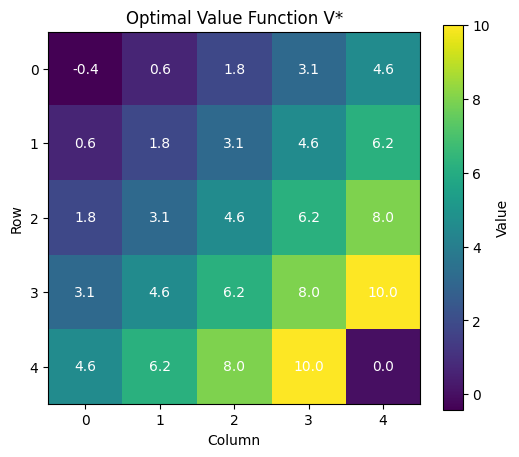

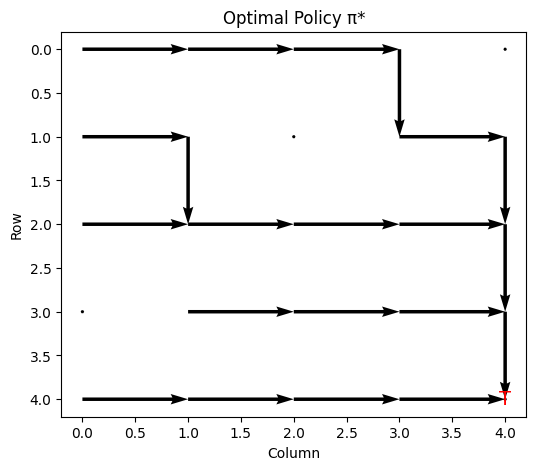

In [29]:
visualize(agent.V, agent.policy)

## Problem 4: Off-policy Monte Carlo with Importance Sampling

In [30]:
from gridworld import GridWorld
from off_policy_mc_agent import OffPolicyMCAgent

def main():
    ENV_SIZE = 5
    env = GridWorld(ENV_SIZE)

    agent = OffPolicyMCAgent(env, gamma=0.9)
    agent.run_off_policy_mc(max_episodes=5000)

    print("Off-Policy MC Value Function (Importance Sampling):")
    print(agent.get_value_function())

    print("\nGreedy Policy from Off-Policy MC:")
    agent.print_policy()
    
main()

Off-Policy MC Value Function (Importance Sampling):
[[ 0.       0.62882  1.8098   3.122    4.58   ]
 [ 0.62882  1.8098   3.122    4.58     6.2    ]
 [ 1.8098   3.122    4.58     6.2      8.     ]
 [ 3.122    4.58     6.2      8.      10.     ]
 [ 4.58     6.2      8.      10.       0.     ]]

Greedy Policy from Off-Policy MC:
['Right|Down', 'Right|Down', 'Right', 'Down', 'Down']
['Right|Down', 'Down', 'Right|Down', 'Right|Down', 'Down']
['Right', 'Right|Down', 'Right|Down', 'Right|Down', 'Down']
['Right|Down', 'Right|Down', 'Right|Down', 'Right|Down', 'Down']
['Right', 'Right', 'Right', 'Right', 'X']


## Comparision between Monte Carlo and Value Iteration

- They are identical everywhere except (0,0).
- That tiny discrepancy at (0,0) is classic MC behavior: first state, fewer effective samples, higher variance.

Key observations:

• 	Wherever VI says Right (0) or Down (2), MC often says "RightDown" → that means both actions have essentially equal value under the MC estimates.

• 	That's exactly what you'd expect in a smooth, monotone grid where moving right or down both lead you closer to the goal with similar returns.

• 	The terminal state (4,4) is -1 in VI and X in MC → consistent semantics.

• 	Grey states are marked as -5 in VI policy and simply not singled out in the MC greedy printout, but behaviorally they're treated as bad states to pass through.

So no real disagreement in behavior—just MC exposing ties where VI picked one argmax.


- Optimization time / complexity:
    - VI reached this solution via a small number of full sweeps over the state space.
    - MC required many episodes but eventually produced a value function that matches VI almost everywhere.
- Episodes vs sweeps:
    - VI: no episodes, just dynamic programming.
    - MC: needed enough off‑policy samples for importance sampling to stabilize.
- Quality of solution:
    - Vᴹᶜ ≈ V^VI everywhere, with only a tiny deviation at the start state.
    - The greedy policy from MC is behaviorally equivalent to VI's policy, differing only where multiple actions are equally good.